Імпорт необхідних бібліотек

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

Завантаження датасету Fashion-MNIST

In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


Візуалізація прикладів з датасету

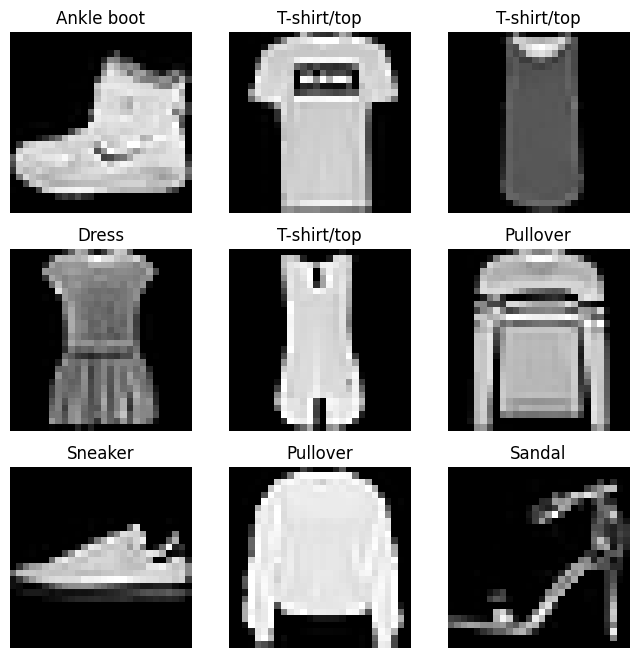

In [26]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.show()

Нормалізація даних

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

Функція побудови MLP

In [5]:
def build_mlp(units, dropout_rate=0.0, l2_value=0.0):
    model = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),

        layers.Dense(units[0], activation="relu",
                     kernel_regularizer=regularizers.l2(l2_value)),
        layers.Dropout(dropout_rate),

        layers.Dense(units[1], activation="relu",
                     kernel_regularizer=regularizers.l2(l2_value)),
        layers.Dropout(dropout_rate),

        layers.Dense(units[2], activation="relu",
                     kernel_regularizer=regularizers.l2(l2_value)),

        layers.Dense(10, activation="softmax")
    ])
    return model

Налаштування експериментів

In [13]:
experiments = [
    # Eксперимент 1
    {
        "name": "Ex1",
        "units": (64, 32, 16),
        "dropout": 0.0,
        "l2": 0.0,
        "lr": 0.001,
        "patience": 5,
        "batch_size": 128
    },

    # Eксперимент 2
    {
        "name": "Ex2_baseline",
        "units": (512, 256, 128),
        "dropout": 0.1,          # 🔽
        "l2": 0.0,
        "lr": 0.001,
        "patience": 6,
        "batch_size": 64
    },

    # Eксперимент 3
    {
        "name": "Ex3_dropout",
        "units": (512, 256, 128),
        "dropout": 0.2,
        "l2": 0.0,
        "lr": 0.0008,
        "patience": 6,
        "batch_size": 64
    },

    # Eксперимент 4
    {
        "name": "Ex4_l2",
        "units": (512, 256, 128),
        "dropout": 0.1,
        "l2": 0.0001,
        "lr": 0.0008,
        "patience": 6,
        "batch_size": 64
    },

    # Eксперимент 5
    {
        "name": "Ex7_complex",
        "units": [1024, 512, 256, 128],
        "dropout": 0.3,
        "l2": 0.00005,
        "lr": 0.0003,
        "patience": 10,
        "batch_size": 64
    }
]

Навчання моделей та збереження результатів

In [14]:
models = {}
histories = {}
val_scores = {}

for exp in experiments:
    print(f"\nНавчання моделі: {exp['name']}")

    # Побудова моделі
    model = build_mlp(
        units=exp["units"],
        dropout_rate=exp["dropout"],
        l2_value=exp["l2"]
    )

    # Adam оптимізатор з експериментальним learning rate
    optimizer = keras.optimizers.Adam(learning_rate=exp["lr"])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Early stopping як гіперпараметр
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=exp["patience"],
        restore_best_weights=True
    )

    history = model.fit(
      x_train, y_train,
      epochs=50,
      batch_size=exp["batch_size"],
      validation_split=0.2,
      callbacks=[early_stop],
      verbose=1
    )

    models[exp["name"]] = model
    histories[exp["name"]] = history
    val_scores[exp["name"]] = max(history.history["val_accuracy"])


Навчання моделі: Ex1
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6657 - loss: 1.0450 - val_accuracy: 0.8389 - val_loss: 0.4766
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8426 - loss: 0.4546 - val_accuracy: 0.8496 - val_loss: 0.4343
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8596 - loss: 0.3999 - val_accuracy: 0.8438 - val_loss: 0.4347
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8656 - loss: 0.3781 - val_accuracy: 0.8611 - val_loss: 0.3922
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8747 - loss: 0.3551 - val_accuracy: 0.8690 - val_loss: 0.3760
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8785 - loss: 0.3406 - val_accuracy: 0.8710 - val_loss: 0.3670
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8843 - loss: 0.3196 - val_accuracy: 0.8770 - val_loss: 0.3528
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8889 - loss: 0.

Порівняння експериментів

In [16]:
for name, score in val_scores.items():
    print(f"{name} best val accuracy: {score:.4f}")

best_model_name = max(val_scores, key=val_scores.get)
best_model = models[best_model_name]

print("\nНайкраща модель:", best_model_name)

Ex1 best val accuracy: 0.8859
Ex2_baseline best val accuracy: 0.9008
Ex3_dropout best val accuracy: 0.9006
Ex4_l2 best val accuracy: 0.8936
Ex7_complex best val accuracy: 0.9016

Найкраща модель: Ex7_complex


Візуалізація кривих навчання

In [17]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.show()

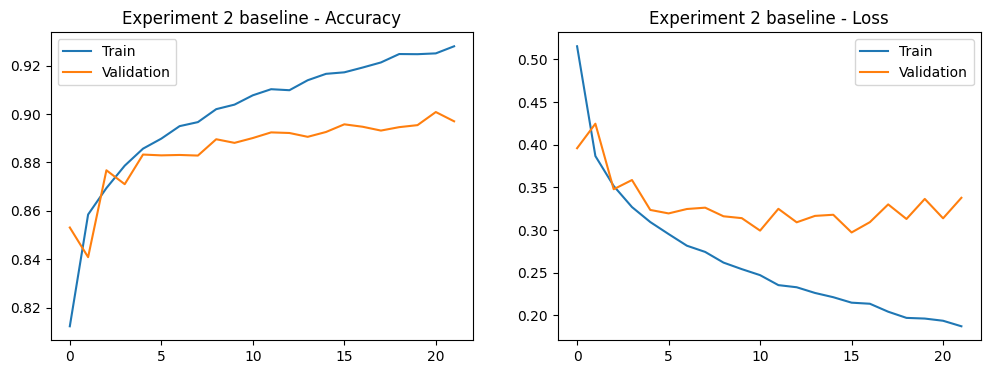

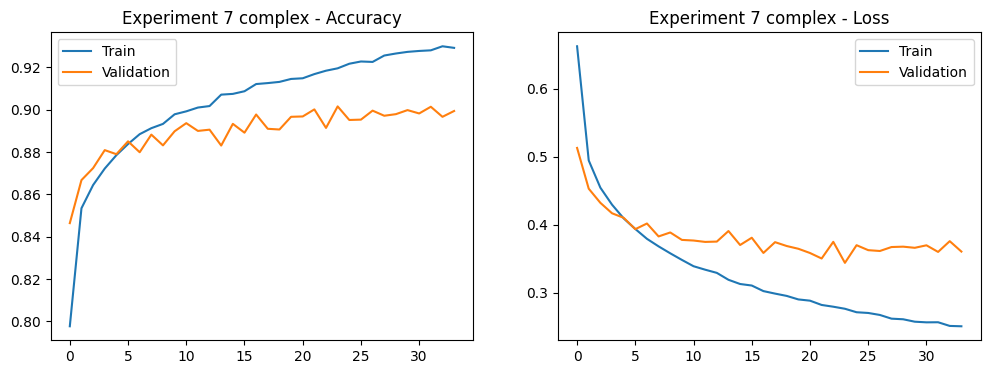

In [19]:
plot_history(histories["Ex2_baseline"], "Experiment 2 baseline")
plot_history(histories["Ex7_complex"], "Experiment 7 complex")

Оцінка найкращої моделі на тестових даних

In [20]:
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"Точність на тестовій вибірці: {test_acc:.4f}")

Точність на тестовій вибірці: 0.8960


Classification Report

In [21]:
y_pred = np.argmax(best_model.predict(x_test), axis=1)
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.86      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.83      0.79      0.81      1000
       Dress       0.90      0.91      0.90      1000
        Coat       0.79      0.85      0.82      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.74      0.71      0.72      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



Візуалізація передбачень моделі

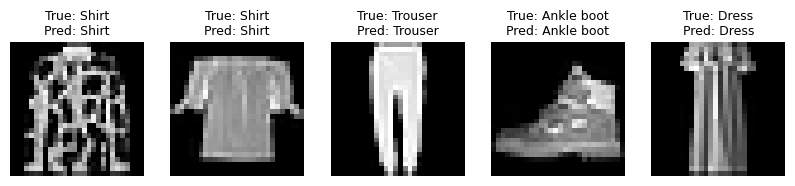

In [25]:
import random

plt.figure(figsize=(10, 4))

for i, idx in enumerate(random.sample(range(len(x_test)), 5)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(
        f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}",
        fontsize=9
    )
    plt.axis("off")

plt.show()

**Висновки**

Перший експеримент з невеликою кількістю нейронів показав низьку точність, що вказує на недонавчання моделі. Після збільшення кількості шарів і нейронів якість класифікації помітно покращилася, що підтвердило необхідність більш складної архітектури для цієї задачі.

У подальших експериментах було використано методи регуляризації для зменшення перенавчання. Найкращі результати було отримано при використанні глибшої архітектури разом з оптимізатором Adam, зменшеним learning rate та механізмом ранньої зупинки, що дозволило досягти балансу між точністю та здатністю моделі до узагальнення.

Експеримент 2 та 7 показали найвищі результати, тому було створено графіки навчання моделі. На графіках для експерименту 2 видно стабільне зростання точності на навчальній вибірці та більш повільне зростання точності на валідаційній. Різниця між кривими невелика, що вказує на слабке перенавчання, при цьому валідаційна точність стабілізується та не погіршується. Для експерименту 7 навчальна точність зростає швидше через складнішу архітектуру моделі, однак валідаційна точність стабілізується на рівні близько 0.9 без різкого погіршення. Це означає, що використані методи регуляризації та ранньої зупинки ефективно обмежують перенавчання.

Загалом, криві навчання показують коректний процес навчання моделей.

Отриманий classification report показує загальну точність моделі на рівні 90%. Найкращі результати спостерігаються для класів Trouser, Sandal, Bag, Sneaker та Ankle boot, для яких значення precision, recall та F1-score перевищують 0.95. Це пов’язано з чіткими та добре відмінними візуальними ознаками цих класів.

Нижчі показники якості спостерігаються для класів Shirt, Pullover та Coat. Ці категорії мають схожі форми та текстури, що ускладнює їх класифікацію. Водночас для цих класів модель демонструє прийнятні значення метрик.

Наведені приклади передбачень показують коректну роботу моделі на тестових зображеннях.